### Prototype notation and supported input formats

You can parse short motifs or full texts using `parse_notation(text, syntax)`. The `syntax` must be one of: `prototype`, `tinynotation`, `humdrum`, `abc`, `lilypond`.

- **prototype**: custom `NOTE:ONSET:DURATION` tokens. Separators: comma, semicolon, or newline.
  - Example:
    - `C4:0:1, D4:1:1, E4:2:1, F#4:3:0.5`
    - Multi-line:
      `A3:0:2; C4:2:1\nE4:3:1.5`
- **tinynotation** (music21 TinyNotation): prepend meter inside the string if needed.
  - Example: `"3/4 c4 d8 f g16 a g f#"`
- **humdrum** (`**kern`): paste the entire Humdrum text.
  - Example (very short):
    ```
    **kern
    *M4/4
    =1
    4c
    4d
    4e
    4f
    *-
    ```
- **abc**: paste full ABC with headers and body.
  - Example:
    ```
    X:1
    T:Example
    M:4/4
    L:1/4
    K:C
    C D E F
    ```
- **lilypond**: paste a LilyPond snippet (requires LilyPond installed for full support).
  - Example:
    ```
    \relative c' { \time 4/4 c4 d e f }
    ```

The function returns a DataFrame with columns `MIDI`, `Global Onset`, `Duration`. When called with `return_meta=True`, it also returns a metadata dict, including `parsed_format`.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from py_scripts.music_utils import (
    parse_prototype_notation,
    parse_notation,
)

# Syntax selector and parsing according to format guidelines

# Choose one: 'prototype' | 'tinynotation' | 'humdrum' | 'abc' | 'lilypond'
NOTATION_SYNTAX = 'humdrum'

# Provide notation text according to the chosen syntax:
# - prototype: NOTE:ONSET:DURATION tokens, separated by comma/semicolon/newline
# - tinynotation: music21 TinyNotation, e.g., "3/4 c4 d8 f g16 a g f#"
# - humdrum: paste full **kern/**humdrum text
# - abc: paste full ABC text (headers + body)
# - lilypond: paste LilyPond snippet
NOTATION_TEXT = """**kern
    *M4/4
    =1
    4c
    4d
    4e
    4f
    4r
    4e
    *-"""

df_notation, meta = parse_notation(NOTATION_TEXT, NOTATION_SYNTAX, return_meta=True)
parsed_format = meta.get('parsed_format')
print(f"Parsed format: {parsed_format}")
print("Parsed notation preview:")
display(df_notation.head(20))

# Quick summary
if 'Duration' in df_notation.columns:
    pos_dur = df_notation.loc[df_notation['Duration'] > 0, 'Duration']
    min_dur_str = str(float(pos_dur.min())) if len(pos_dur) > 0 else "n/a"
else:
    min_dur_str = "n/a"

print(f"Summary: rows={len(df_notation)}, unique_pitches={df_notation['MIDI'].nunique()}, min_duration={min_dur_str}")



Parsed format: humdrum
Parsed notation preview:


,MIDI,Global Onset,Duration
0,60,0.0,1.0
1,62,1.0,1.0
2,64,2.0,1.0
3,65,3.0,1.0
4,64,5.0,1.0


Summary: rows=5, unique_pitches=4, min_duration=1.0


In [3]:
# Binary conversion and visualization (refactored to py_scripts)
import numpy as np
import pandas as pd
from py_scripts.music_utils import create_binary_matrix, plot_binary_matrix

# Configuration
BINARY_RESOLUTION_METHOD = 'manual'   # 'auto' | 'manual' | 'standard'
BINARY_MANUAL_RES = 0.5            # e.g., 0.5 when using 'manual'
Y_AXIS_MODE = 'minmax'              # 'full' | 'minmax' | 'chroma'
Y_AXIS_MIN = 60                   # optional int when Y_AXIS_MODE=='minmax'
Y_AXIS_MAX = 71                   # optional int when Y_AXIS_MODE=='minmax'

PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'

# Build binary matrix
binary_matrix_df, meta = create_binary_matrix(
    df_notation,
    resolution_method=BINARY_RESOLUTION_METHOD,
    manual_resolution=BINARY_MANUAL_RES,
    y_mode=Y_AXIS_MODE,
    midi_low=Y_AXIS_MIN,
    midi_high=Y_AXIS_MAX,
    row_order="high_to_low"
)

print(f"Binary matrix shape: {binary_matrix_df.shape}")
print(f"Resolution: {meta['resolution']}, columns: {meta['num_cols']}, y_mode: {meta['y_mode']}")

# Plot using the same backend as parsing cell (if defined), else default to 'plt'
backend_to_use = PLOTTING_BACKEND

# If measure offsets were computed earlier, you can pass them here.
# In this notebook, measure offsets are inside `results` items if needed; we default to None
plot_binary_matrix(
    binary_matrix_df,
    meta,
    backend=backend_to_use,
    measure_offsets=None,
    show_measure_lines=True,
    show=True,
    plot_width=1200, plot_height=800, dpi=100,
    zoom_drag_dim="both", zoom_wheel_dim="width",
    pitch_labels=True,
    save_html=True,
    save_html_path="binary_matrix_kernel.html",
    # save_png_path="binary_matrix.png",
    open_html_after_save=False
)


Binary matrix shape: (12, 12)
Resolution: 0.5, columns: 12, y_mode: minmax


Data saved successfully to c:\Users\egorp\Nextcloud\code\public_repos\camat_v2\CAMAT_revamped\binary_matrix_kernel.html at 2025-10-04T13:18:02.


figure(id='p1002', ...)

In [4]:
print(binary_matrix_df)
print(meta)

[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]]
{'resolution': 0.5, 'num_cols': 12, 'time_end': 6.0, 'total_duration': 6.0, 'min_positive_duration': 1.0, 'y_mode': 'minmax', 'y_min': 60, 'y_max': 71, 'midi_low': 60, 'midi_high': 71, 'row_order': 'high_to_low', 'origin': 'upper'}


interactive cell: try to load binary_matrix_df in the ui!

In [ ]:
from py_scripts.music_utils import orient_binary_matrix
from py_scripts.binary_matrix_designer import binary_matrix_designer

# Prepare canonical data/view versions once so both orientations are handy
binary_matrix_ui_data = orient_binary_matrix(binary_matrix_df, meta, target_origin="lower")
binary_matrix_ui_view = orient_binary_matrix(binary_matrix_df, meta, target_origin="upper")
binary_matrix_ui_meta = dict(meta)
binary_matrix_ui_meta["origin"] = "lower"
binary_matrix_ui_meta["row_order"] = "low_to_high"

ui_widget = binary_matrix_designer(
    rows=binary_matrix_ui_data.shape[0],
    cols=binary_matrix_ui_data.shape[1],
    prototype=binary_matrix_ui_data,
    flip_vertical=True,
    prototype_meta=binary_matrix_ui_meta,
    display_ui=False,
)
display(ui_widget)


In [7]:
print(binary_matrix_ui)

[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]]


now try to parse a df from binary matrix:

In [11]:
# Convert a binary matrix back into a notes DataFrame and sanity-check round trip
import numpy as np
import pandas as pd
from py_scripts.music_utils import (
    binary_matrix_to_df_from_bounds,
)

# Derive a DataFrame from the UI/exported binary matrix
# - binary_matrix_ui: defined by the interactive editor above
# - resolution: grid size (quarterLength units)
# - midi_low: lowest MIDI in the view (bottom row when flipped=True)
df_ui = binary_matrix_to_df_from_bounds(
    binary_matrix_ui,
    resolution=0.5,
    midi_low=60,
    flipped=True,
)

print(df_ui)

   MIDI  Global Onset  Duration
0    60           0.0       1.0
1    62           1.0       1.0
2    64           2.0       1.0
3    65           3.0       1.0
4    64           5.0       1.0


and make a symbolic representation from it:

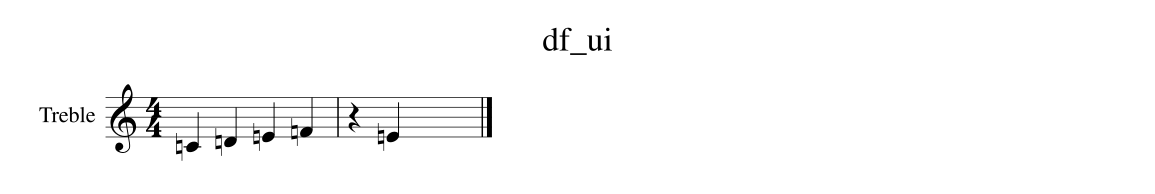

Rendered 1 page(s). Variables available: MEI_LAST, MUSICXML_LAST.


In [14]:
from py_scripts.music21_render import (
    df_to_music21,
    music21_to_musicxml_string,
    render_with_verovio_from_musicxml,
)

# Example: render df_ui (created above). If not present, fall back to a tiny demo
target_df = df_ui
target_df_name = 'df_ui'

for name, value in globals().items():
    if value is target_df and name not in {'target_df', 'target_df_name'}:
        target_df_name = name
        break

score = df_to_music21(
    target_df,
    time_signature='4/4',
    unit_quarter_length=1.0,
    piece_title=target_df_name,
    clef_config='AUTO', # 'G', 'F', 'GF', or 'AUTO'
    split_midi=59,
    voices_per_stave=1,  # 1 or 2
    enforce_accidentals=True,  # force naturals/sharps/flats to be shown
)
musicxml_str = music21_to_musicxml_string(score)
mei_str, svg_pages = render_with_verovio_from_musicxml(musicxml_str, scale=55)

# Expose strings for export if needed
MEI_LAST = mei_str
MUSICXML_LAST = musicxml_str
print(f"Rendered {len(svg_pages)} page(s). Variables available: MEI_LAST, MUSICXML_LAST.")
